<img src="../../Practica 3/informe/imagenes/logo-ups-home.png" width="220">

# UNIVERSIDAD POLITÉCNICA SALESIANA
### Carrera de Computación — Visión Artificial
**Período lectivo:** Abril – Agosto 2026&nbsp;&nbsp;|&nbsp;&nbsp;**Docente:** Vladimir Robles Bykbaev

## Proyecto Integrador Final — Parte II
### Evaluación de los detectores HOG + SVM lineal — Camión grande (frontal + lateral)

**Estudiantes:** Paul Naspud, Camila Ramirez

Este cuaderno evalúa los dos detectores ya entrenados (`dataset/detector_frontal.yml` y
`dataset/detector_lateral.yml`, ver `entrenar_modelo.py`) y genera las figuras para el
informe. **No reentrena ningún modelo.**

Contenido:
1. Evaluación de accuracy (validación held-out) para ambas vistas.
2. Matriz de confusión.
3. Pipeline de transformación de imágenes (recorte) — positivos y negativos.
4. Evaluación cualitativa: detección sobre imágenes completas con distintos umbrales.

Las figuras se guardan en dos carpetas dentro de `dataset/`:
- `dataset/entrenamiento/` — ejemplos del pipeline de recorte (cómo se construyó el dataset).
- `dataset/testeo/` — matriz de confusión y resultados de detección con distintos umbrales.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

PROJECT_DIR = Path.cwd()
ARTIFACTS_DIR = PROJECT_DIR.parent / "artifcats"
DATASET_DIR = PROJECT_DIR / "dataset"

ENTRENAMIENTO_DIR = DATASET_DIR / "entrenamiento"
TESTEO_DIR = DATASET_DIR / "testeo"
ENTRENAMIENTO_DIR.mkdir(exist_ok=True)
TESTEO_DIR.mkdir(exist_ok=True)

VAL_FRACTION = 0.15
SEED = 42
np.random.seed(SEED)

# Configuración de las dos vistas (debe coincidir con entrenar_modelo.py)
VIEWS = {
    "frontal": dict(
        win_size=(96, 96),
        pos_raw_dir=DATASET_DIR / "positives_raw_frontal",
        neg_raw_dir=DATASET_DIR / "negatives_raw_frontal",
        detector_path=DATASET_DIR / "detector_frontal.yml",
        win_stride=(16, 16),
    ),
    "lateral": dict(
        win_size=(128, 64),
        pos_raw_dir=DATASET_DIR / "positives_raw_lateral",
        neg_raw_dir=DATASET_DIR / "negatives_raw_lateral",
        detector_path=DATASET_DIR / "detector_lateral.yml",
        win_stride=(24, 16),
    ),
}


def crop_with_padding(img, x, y, w, h, pad_ratio):
    ih, iw = img.shape[:2]
    pad_w, pad_h = w * pad_ratio, h * pad_ratio
    x0 = max(0, int(x - pad_w))
    y0 = max(0, int(y - pad_h))
    x1 = min(iw, int(x + w + pad_w))
    y1 = min(ih, int(y + h + pad_h))
    if x1 <= x0 or y1 <= y0:
        return None
    return img[y0:y1, x0:x1]


def load_detector(yml_path, win_size):
    fs = cv2.FileStorage(str(yml_path), cv2.FileStorage_READ)
    detector_vector = fs.getNode("svm_detector").mat().flatten()
    fs.release()
    w, b = detector_vector[:-1], detector_vector[-1]
    hog = cv2.HOGDescriptor(win_size, (16, 16), (8, 8), (8, 8), 9)
    hog.setSVMDetector(detector_vector.astype(np.float32))
    return hog, w, b


for name, cfg in VIEWS.items():
    hog, w, b = load_detector(cfg["detector_path"], cfg["win_size"])
    cfg["hog"], cfg["w"], cfg["b"] = hog, w, b

print("Detectores cargados:", list(VIEWS.keys()))


Detectores cargados: ['frontal', 'lateral']


## 1. Evaluación de accuracy (conjunto de validación held-out)

`positives_raw_*` / `negatives_raw_*` son los recortes originales (nunca aumentados).
Para evaluar sin fuga de información, se reconstruye aquí el mismo 15% de validación
que se aparta ANTES de aumentar/entrenar (misma semilla `SEED=42`), y se calculan las
métricas del clasificador SVM lineal directamente sobre esos recortes RAW — nunca
vistos en su forma aumentada durante el entrenamiento.


In [2]:
def score_imagenes(paths, win_size, hog, w, b):
    scores = []
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        if img.shape[:2] != (win_size[1], win_size[0]):
            img = cv2.resize(img, win_size)
        feat = hog.compute(img).flatten()
        scores.append(float(np.dot(feat, w) + b))
    return np.array(scores)


metrics_por_vista = {}
for name, cfg in VIEWS.items():
    pos_paths = sorted(cfg["pos_raw_dir"].glob("*.jpg"))
    neg_paths = sorted(cfg["neg_raw_dir"].glob("*.jpg"))

    _, pos_val_paths = train_test_split(pos_paths, test_size=VAL_FRACTION, random_state=SEED)
    _, neg_val_paths = train_test_split(neg_paths, test_size=VAL_FRACTION, random_state=SEED)

    scores_pos = score_imagenes(pos_val_paths, cfg["win_size"], cfg["hog"], cfg["w"], cfg["b"])
    scores_neg = score_imagenes(neg_val_paths, cfg["win_size"], cfg["hog"], cfg["w"], cfg["b"])

    y_true = np.concatenate([np.ones(len(scores_pos)), np.zeros(len(scores_neg))])
    y_score = np.concatenate([scores_pos, scores_neg])
    y_pred = (y_score > 0).astype(int)

    metrics_por_vista[name] = dict(
        y_true=y_true, y_pred=y_pred, y_score=y_score,
        n_pos=len(scores_pos), n_neg=len(scores_neg),
    )

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"=== Vista {name.upper()} — validación held-out ===")
    print(f"muestras evaluadas : {len(y_true)} ({len(scores_pos)} positivas + {len(scores_neg)} negativas)")
    print(f"accuracy           : {acc:.4f}")
    print(f"precisión          : {prec:.4f}")
    print(f"exhaustividad      : {rec:.4f}")
    print(f"F1                 : {f1:.4f}")
    print()


=== Vista FRONTAL — validación held-out ===
muestras evaluadas : 4604 (593 positivas + 4011 negativas)
accuracy           : 0.8960
precisión          : 0.5633
exhaustividad      : 0.8550
F1                 : 0.6792



=== Vista LATERAL — validación held-out ===
muestras evaluadas : 4343 (332 positivas + 4011 negativas)
accuracy           : 0.8856
precisión          : 0.3884
exhaustividad      : 0.8645
F1                 : 0.5359



## 2. Matriz de confusión

Una matriz por vista (frontal y lateral), calculada sobre el mismo conjunto de
validación held-out de la sección anterior.


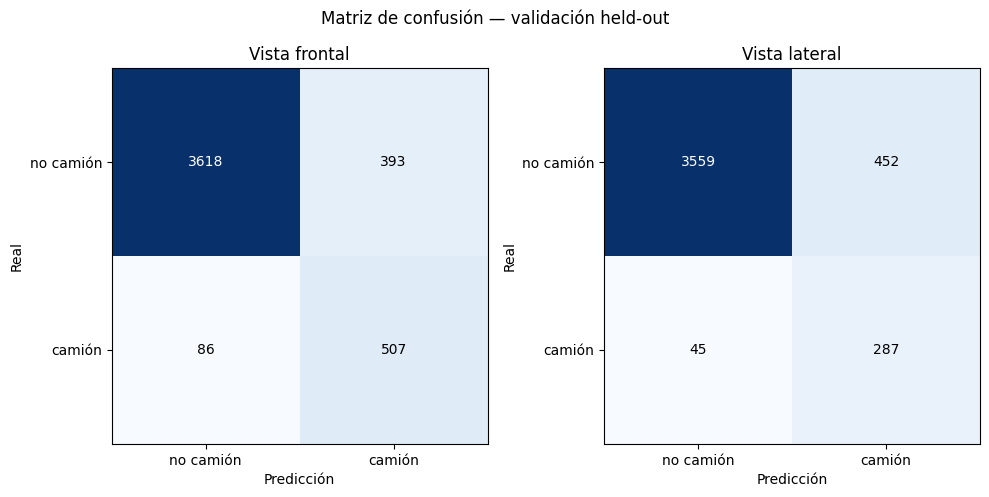

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, m) in zip(axes, metrics_por_vista.items()):
    cm = confusion_matrix(m["y_true"], m["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["no camión", "camión"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["no camión", "camión"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Vista {name}")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.suptitle("Matriz de confusión — validación held-out")
plt.tight_layout()
plt.savefig(TESTEO_DIR / "figura_matriz_confusion.png", dpi=150)
plt.show()


## 3. Pipeline de transformación de imágenes (recorte del dataset)

Se muestran 3 ejemplos de camiones (positivos) y 5 ejemplos de cosas que NO son
camiones (negativos: persona, señal de tránsito, valla publicitaria, casa y una escena
de interior), cada uno con la imagen original (bbox en rojo/verde) y el recorte final
redimensionado a la ventana HOG correspondiente — igual que hace `preparar_dataset.py`.


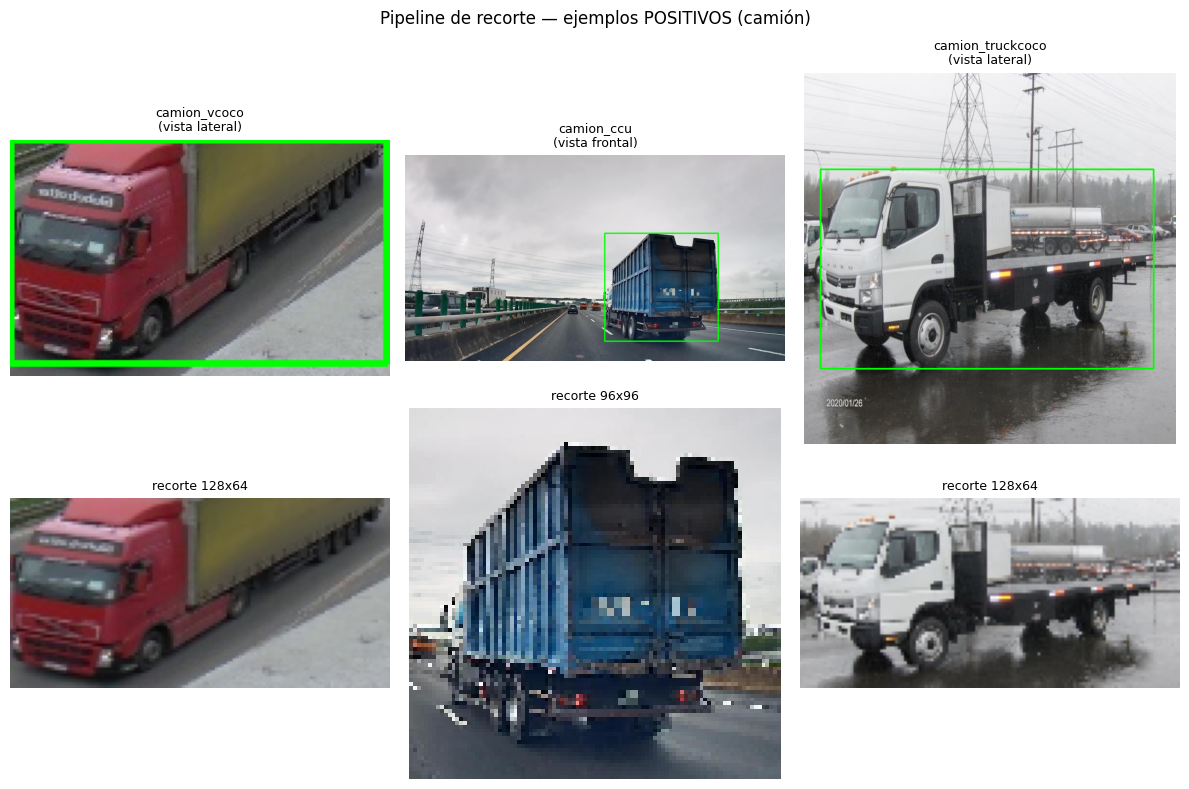

In [4]:
# Ejemplos POSITIVOS (camión): (ruta relativa a ARTIFACTS_DIR, bbox, vista, etiqueta)
ejemplos_positivos = [
    ("V.coco/train/Image_000188_jpg.rf.7SCpxAYE2r9gE4tcGWzr.jpg", (0, 0, 165, 98), "lateral", "camion_vcoco"),
    ("CCU-Truck.coco/train/C_187_jpg.rf.EfdcgkvSfQBQ9wtqtbL3.jpg", (1306, 511, 742, 705), "frontal", "camion_ccu"),
    ("Truck.coco/train/1365-_jpg.rf.wCAa2UgkMuyePmKM0scz.jpg", (28, 167, 573, 343), "lateral", "camion_truckcoco"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (rel_path, bbox, vista, tag) in enumerate(ejemplos_positivos):
    x, y, w, h = bbox
    win_size = VIEWS[vista]["win_size"]
    img = cv2.imread(str(ARTIFACTS_DIR / rel_path))
    original_bbox = img.copy()
    cv2.rectangle(original_bbox, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), max(2, img.shape[1] // 300))
    crop = crop_with_padding(img, x, y, w, h, 0.12)
    crop_resized = cv2.resize(crop, win_size)

    cv2.imwrite(str(ENTRENAMIENTO_DIR / f"positivo_{tag}_1_original.jpg"), original_bbox)
    cv2.imwrite(str(ENTRENAMIENTO_DIR / f"positivo_{tag}_2_recorte.jpg"), crop_resized)

    axes[0, col].imshow(cv2.cvtColor(original_bbox, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"{tag}\n(vista {vista})", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"recorte {win_size[0]}x{win_size[1]}", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Pipeline de recorte — ejemplos POSITIVOS (camión)")
plt.tight_layout()
plt.savefig(ENTRENAMIENTO_DIR / "figura_pipeline_positivos.png", dpi=150)
plt.show()


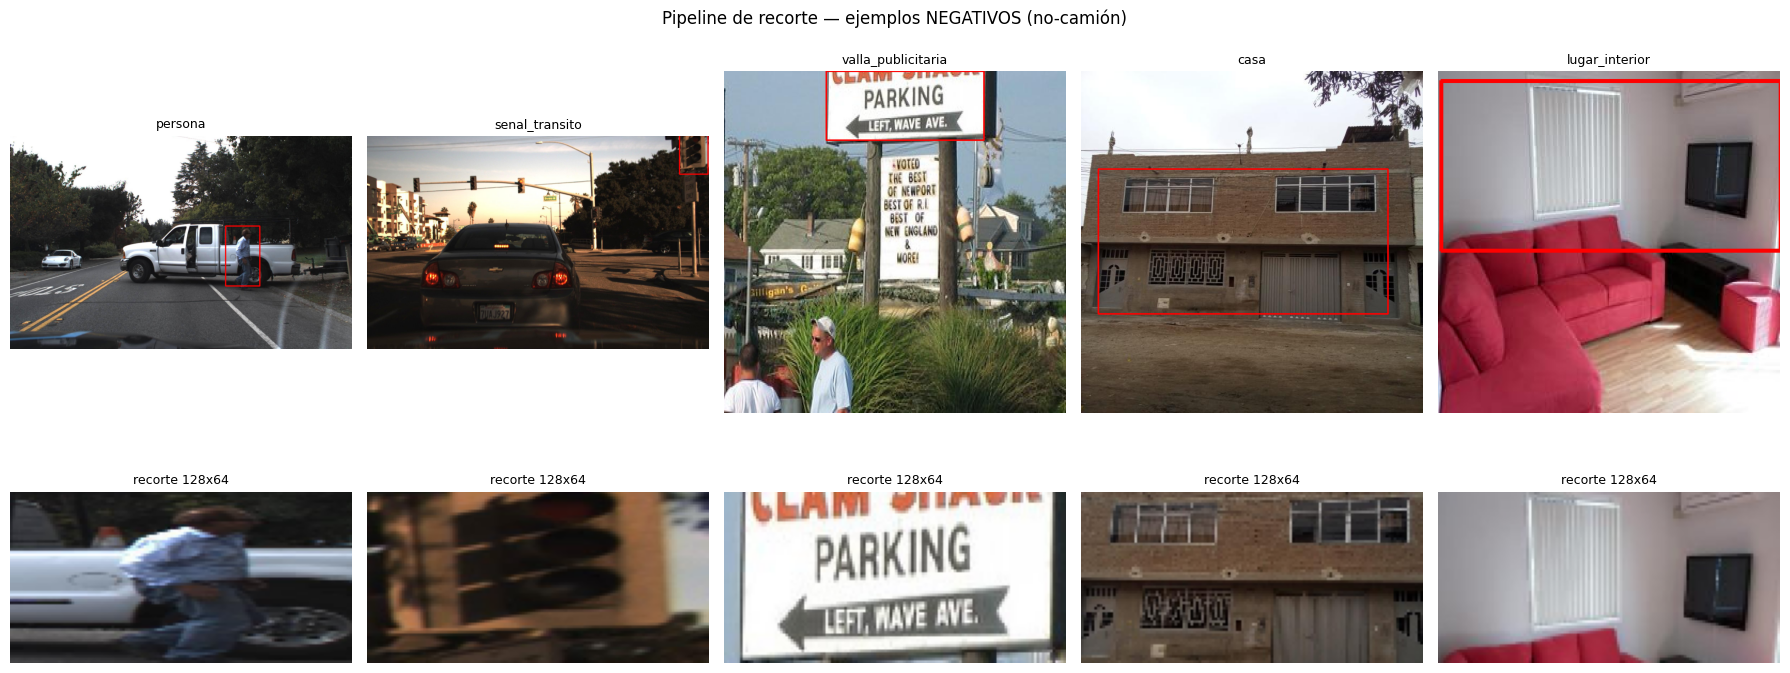

In [5]:
# Ejemplos NEGATIVOS (no-camión): (ruta relativa, bbox, pad_ratio, etiqueta)
ejemplos_negativos = [
    ("Self Driving Car.v2-fixed-large.coco/export/1478900293262192339_jpg.rf.ff09b974dd1b0563cb74c1b25b1be7a0.jpg",
     (1210, 510, 192, 336), 0.05, "persona"),
    ("Self Driving Car.v2-fixed-large.coco/export/1478732125394959531_jpg.rf.c525b71541fc4dbb717e1c164bda0998.jpg",
     (1754, 1, 160, 218), 0.05, "senal_transito"),
    ("Billboard Detector.v2i.coco/train/205782513_ad32243487_z_jpg.rf.520fc31752a9ccecfdd87044d68a567b.jpg",
     (191, 0, 295.95, 129.604), 0.05, "valla_publicitaria"),
    ("TipoCasa_V2.v2i.folder/train/Casa/14010519050014_1_jpg.rf.d7ed57bd8aeb4529d68d3928b29e802b.jpg",
     (32, 183, 542, 271), 0.0, "casa"),
    ("Places365/val_256/Places365_val_00009918.jpg",
     (2, 7, 254, 127), 0.0, "lugar_interior"),
]

WIN_NEG = VIEWS["lateral"]["win_size"]  # ventana genérica para mostrar el recorte negativo

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for col, (rel_path, bbox, pad_ratio, tag) in enumerate(ejemplos_negativos):
    x, y, w, h = bbox
    img = cv2.imread(str(ARTIFACTS_DIR / rel_path))
    original_bbox = img.copy()
    cv2.rectangle(original_bbox, (int(x), int(y)), (int(x + w), int(y + h)), (0, 0, 255), max(2, img.shape[1] // 300))
    crop = crop_with_padding(img, x, y, w, h, pad_ratio)
    crop_resized = cv2.resize(crop, WIN_NEG)

    cv2.imwrite(str(ENTRENAMIENTO_DIR / f"negativo_{tag}_1_original.jpg"), original_bbox)
    cv2.imwrite(str(ENTRENAMIENTO_DIR / f"negativo_{tag}_2_recorte.jpg"), crop_resized)

    axes[0, col].imshow(cv2.cvtColor(original_bbox, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(tag, fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"recorte {WIN_NEG[0]}x{WIN_NEG[1]}", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Pipeline de recorte — ejemplos NEGATIVOS (no-camión)")
plt.tight_layout()
plt.savefig(ENTRENAMIENTO_DIR / "figura_pipeline_negativos.png", dpi=150)
plt.show()


## 4. Evaluación cualitativa: detección en imágenes completas

Se corre `detectMultiScale` (igual que la app en C++) sobre imágenes completas
—distintas a las usadas en el pipeline de recorte— con tres valores de `hitThreshold`
(0.4, 0.6 y 0.8), el mismo parámetro que usa `truck_detector_dual.cpp`.

Primero, 3 imágenes con camión (probando cada una con el modelo que le corresponde,
frontal o lateral); luego, 5 imágenes SIN camión, probando ambos modelos a la vez para
ver si aparecen falsos positivos.


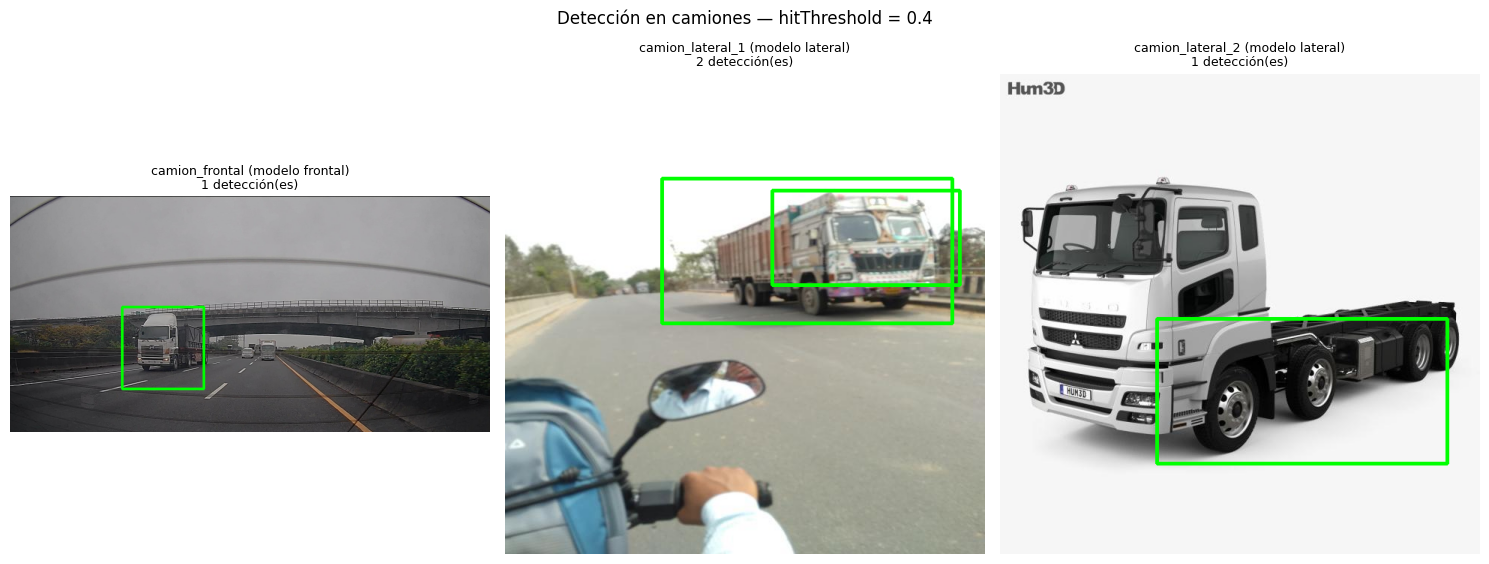

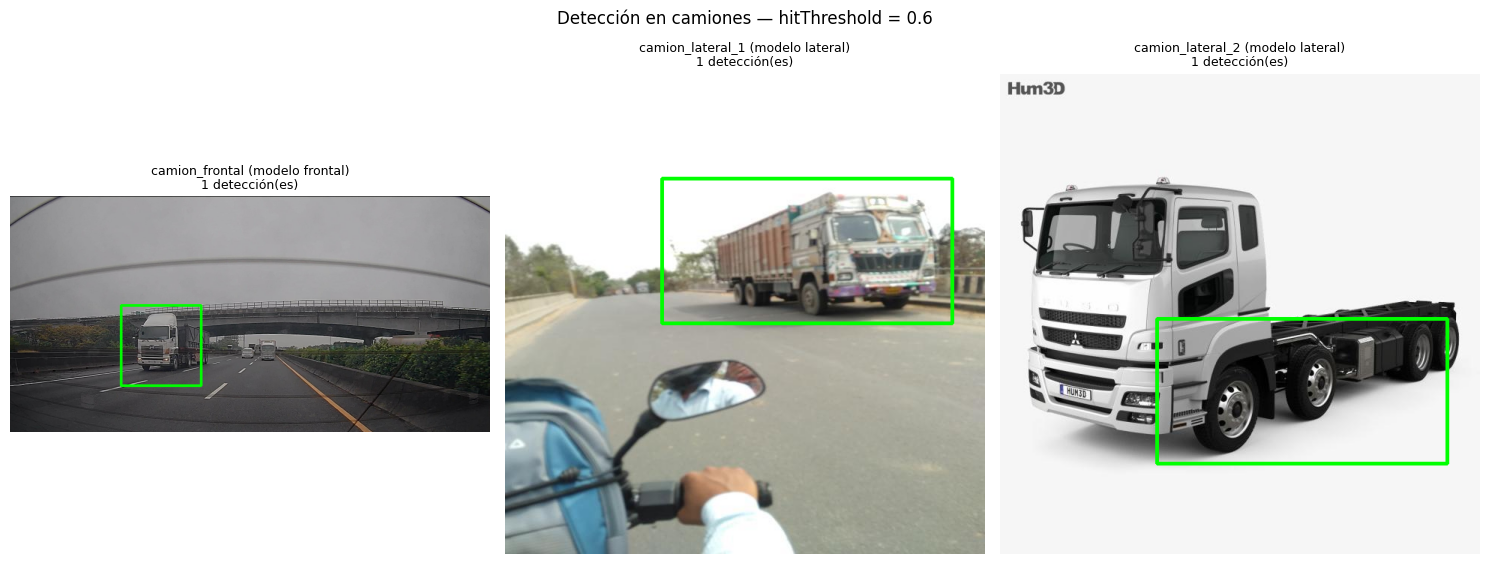

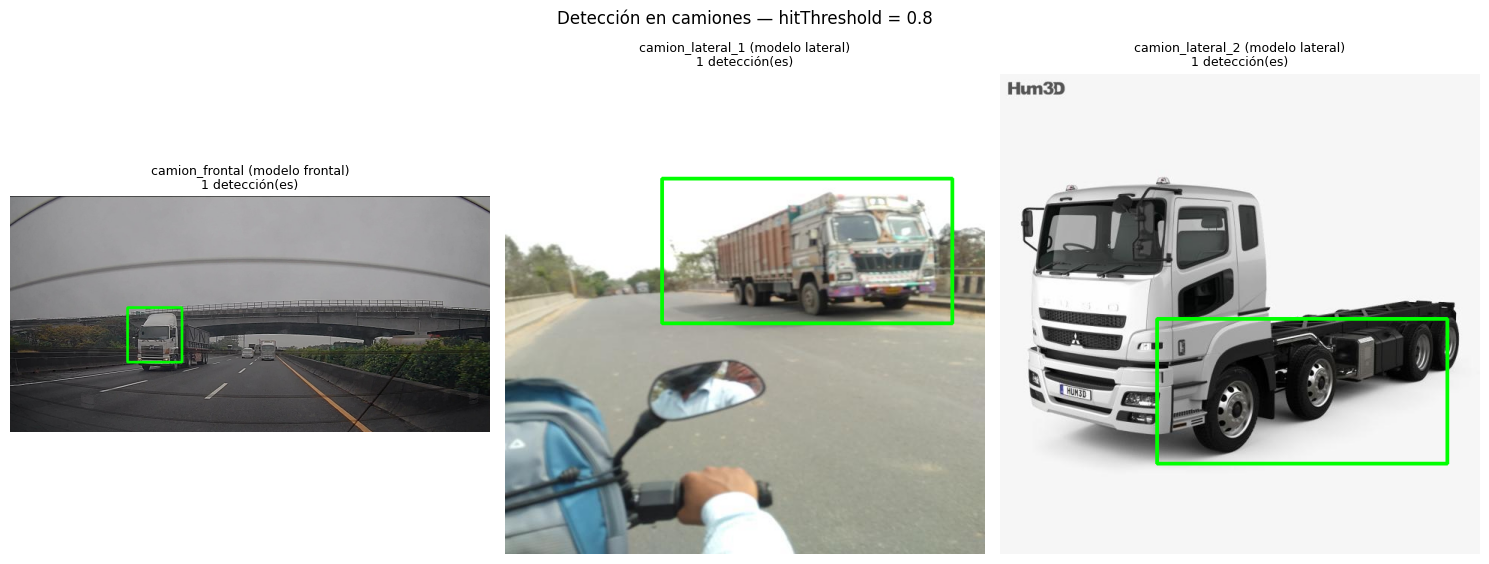

In [6]:
UMBRALES = [0.4, 0.6, 0.8]

# (ruta relativa, vista/modelo a usar, etiqueta)
tests_positivos = [
    ("CCU-Truck.coco/train/C_961_jpg.rf.JC7gt3UCJJZRgr80rWRS.jpg", "frontal", "camion_frontal"),
    ("Truck.coco/train/Datacluster-Truck-149-_jpg.rf.0rCgbPZ2rIJ0eTQmqXnU.jpg", "lateral", "camion_lateral_1"),
    ("Truck.coco/train/Mitsubishi_Fuso_Heavy_Chassis_Truck__jpg.rf.9EqyeJzzJdYsuMvAotJz.jpg", "lateral", "camion_lateral_2"),
]


def preparar_escena(rel_path, max_lado=900):
    img_color = cv2.imread(str(ARTIFACTS_DIR / rel_path))
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    if max(gray.shape[:2]) > max_lado:
        s = max_lado / max(gray.shape[:2])
        gray = cv2.resize(gray, None, fx=s, fy=s)
        img_color = cv2.resize(img_color, None, fx=s, fy=s)
    return img_color, gray


escenas_pos = [(preparar_escena(rel), vista, tag) for rel, vista, tag in tests_positivos]

for t in UMBRALES:
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    for ax, ((img_color, gray), vista, tag) in zip(axes, escenas_pos):
        cfg = VIEWS[vista]
        vis = img_color.copy()
        boxes, weights = cfg["hog"].detectMultiScale(
            gray, hitThreshold=t, winStride=cfg["win_stride"], scale=1.2
        )
        for (x, y, w, h) in boxes:
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{tag} (modelo {vista})\n{len(boxes)} detección(es)", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Detección en camiones — hitThreshold = {t}")
    plt.tight_layout()
    plt.savefig(TESTEO_DIR / f"figura_test_camion_umbral_{t}.png", dpi=150)
    plt.show()


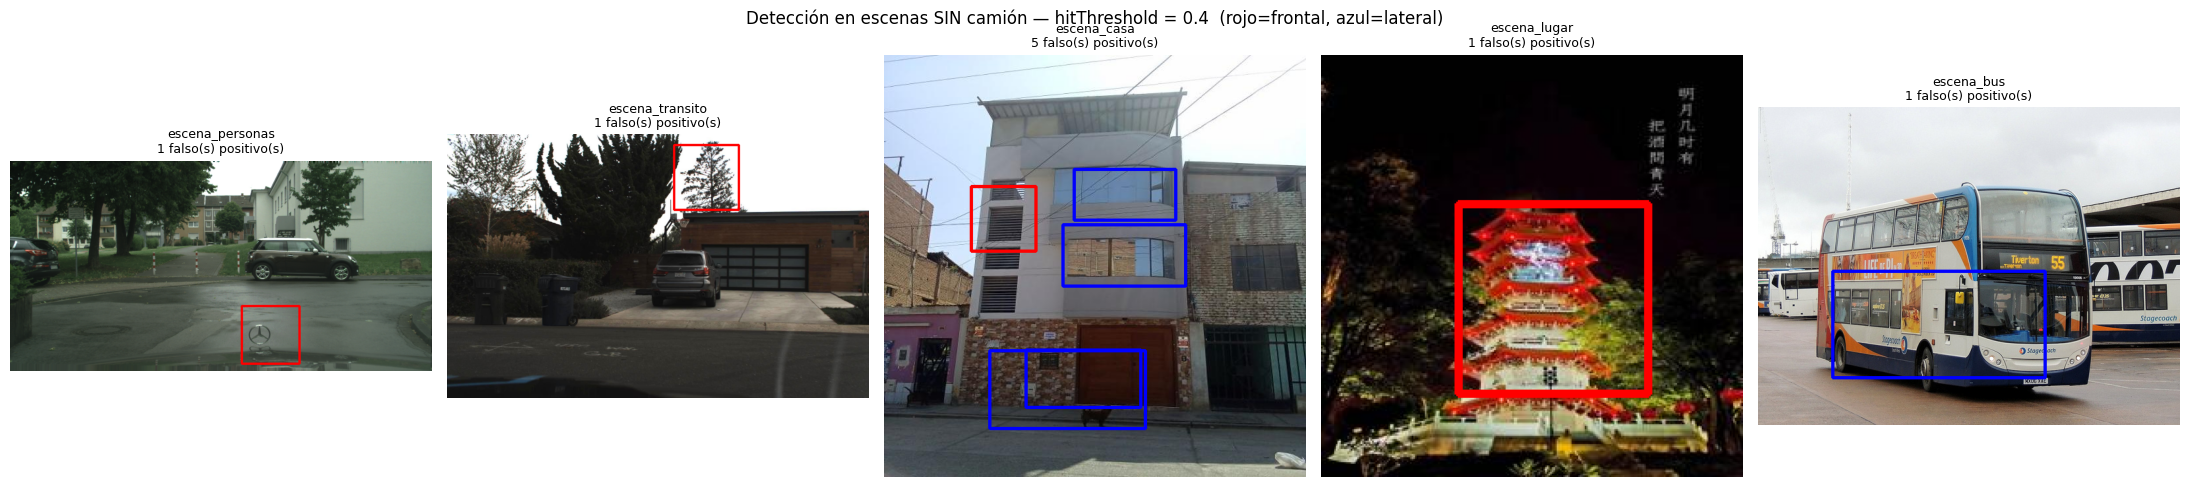

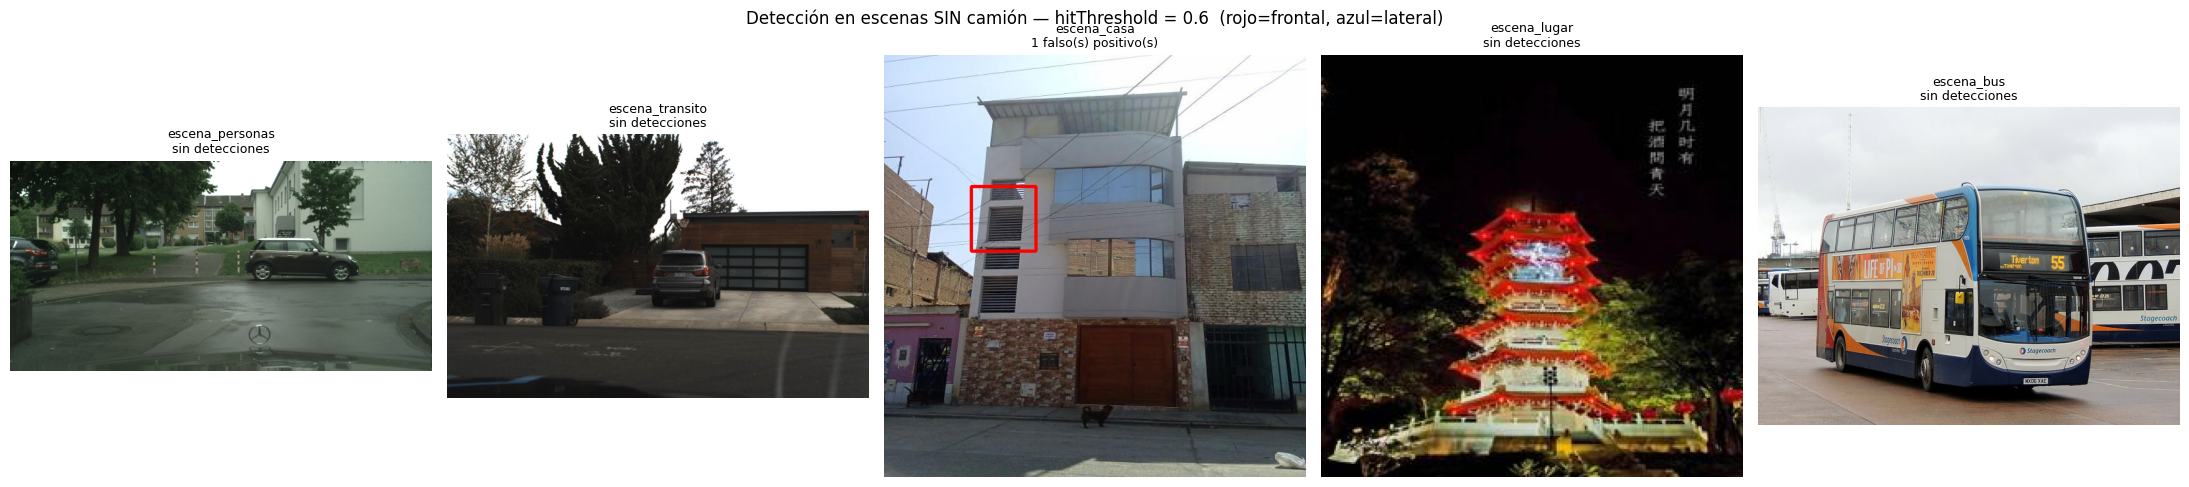

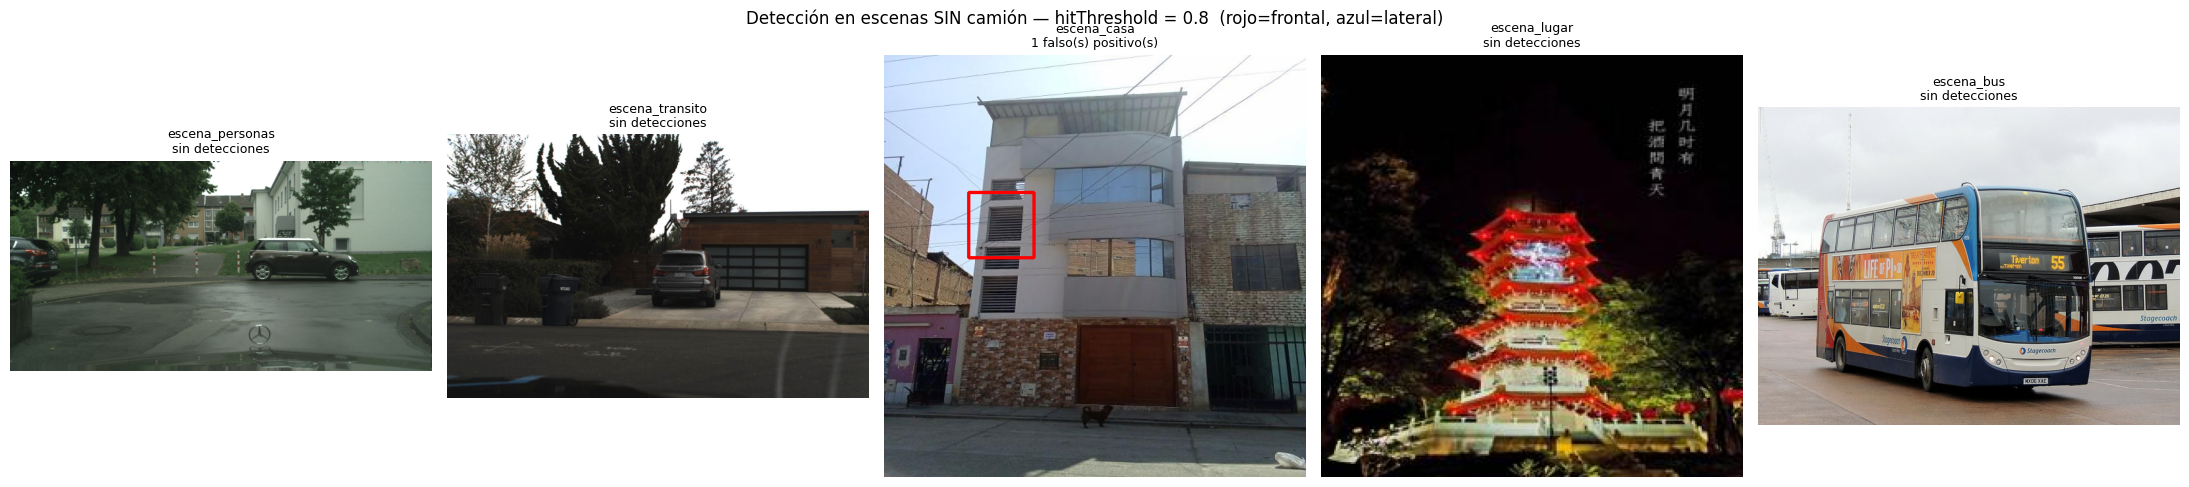

In [7]:
# 5 imágenes SIN camión: se prueban ambos modelos (frontal=rojo, lateral=azul)
tests_negativos = [
    ("Citypersons.coco/train/bochum_000000_004229_leftImg8bit_png.rf.weBkcwzLBXpcFP5ZAxfM.png", "escena_personas"),
    ("Self Driving Car.v2-fixed-large.coco/export/1478901109634771523_jpg.rf.A9Ltc4rifIx3ZkUU4EwF.jpg", "escena_transito"),
    ("TipoCasa_V2.v2i.folder/train/Casa/14010113049030_1_jpg.rf.d253baed650822cded70894ccbb56ae4.jpg", "escena_casa"),
    ("Places365/val_256/Places365_val_00003425.jpg", "escena_lugar"),
    ("Vehicles-coco.coco/train/000000383917_jpg.rf.SCzMQcw86tVWbSxF6IgT.jpg", "escena_bus"),
]

escenas_neg = [(preparar_escena(rel), tag) for rel, tag in tests_negativos]

for t in UMBRALES:
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    for ax, ((img_color, gray), tag) in zip(axes, escenas_neg):
        vis = img_color.copy()
        n_total = 0
        for vista, color in [("frontal", (0, 0, 255)), ("lateral", (255, 0, 0))]:
            cfg = VIEWS[vista]
            boxes, weights = cfg["hog"].detectMultiScale(
                gray, hitThreshold=t, winStride=cfg["win_stride"], scale=1.2
            )
            n_total += len(boxes)
            for (x, y, w, h) in boxes:
                cv2.rectangle(vis, (x, y), (x + w, y + h), color, 3)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        estado = f"{n_total} falso(s) positivo(s)" if n_total else "sin detecciones"
        ax.set_title(f"{tag}\n{estado}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Detección en escenas SIN camión — hitThreshold = {t}  (rojo=frontal, azul=lateral)")
    plt.tight_layout()
    plt.savefig(TESTEO_DIR / f"figura_test_notruck_umbral_{t}.png", dpi=150)
    plt.show()


## Resumen

- `dataset/entrenamiento/` — recortes originales + pipeline de transformación (positivos y negativos), y las figuras combinadas `figura_pipeline_positivos.png` / `figura_pipeline_negativos.png`.
- `dataset/testeo/` — `figura_matriz_confusion.png` y las figuras de detección por umbral (`figura_test_camion_umbral_*.png`, `figura_test_notruck_umbral_*.png`).

Ningún modelo fue reentrenado en este cuaderno.
